In [2]:
import pandas as pd
import seaborn as sns 
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression,Ridge,Lasso
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error,mean_squared_error
from sklearn.model_selection import train_test_split
import numpy as np

In [3]:
dataset = pd.read_csv(r'R:\aiml\Machine_Learning\house_data.csv')

In [4]:
dataset.shape

(500, 13)

In [5]:
dataset.head(10)

,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,price
0,3,3.0,1925,11550,1.5,0,0,3,1425,500,1917,0,490391.0
1,6,5.0,3984,15936,1.5,0,0,3,3984,0,2010,0,912714.0
2,4,4.0,3178,15890,2.0,0,0,2,2178,1000,1901,0,771954.0
3,4,4.5,3469,10407,2.0,0,3,3,1969,1500,1992,0,867815.0
4,2,2.0,1922,13454,1.0,0,0,3,1922,0,1912,0,519590.0
5,2,2.0,1773,10638,2.0,0,0,4,1773,0,1903,0,415892.0
6,2,2.5,1741,12187,2.0,0,0,2,1241,500,1941,0,NaN
7,5,5.0,3829,30632,1.5,0,0,3,3829,0,2008,0,925002.0
8,4,4.5,3533,14132,1.0,0,0,3,2533,1000,1973,0,834542.0
9,4,4.0,2943,20601,2.0,0,0,4,2943,0,1960,0,753522.0


In [12]:
dataset['price'].fillna(dataset['price'].mean(),inplace=True)

<Axes: >

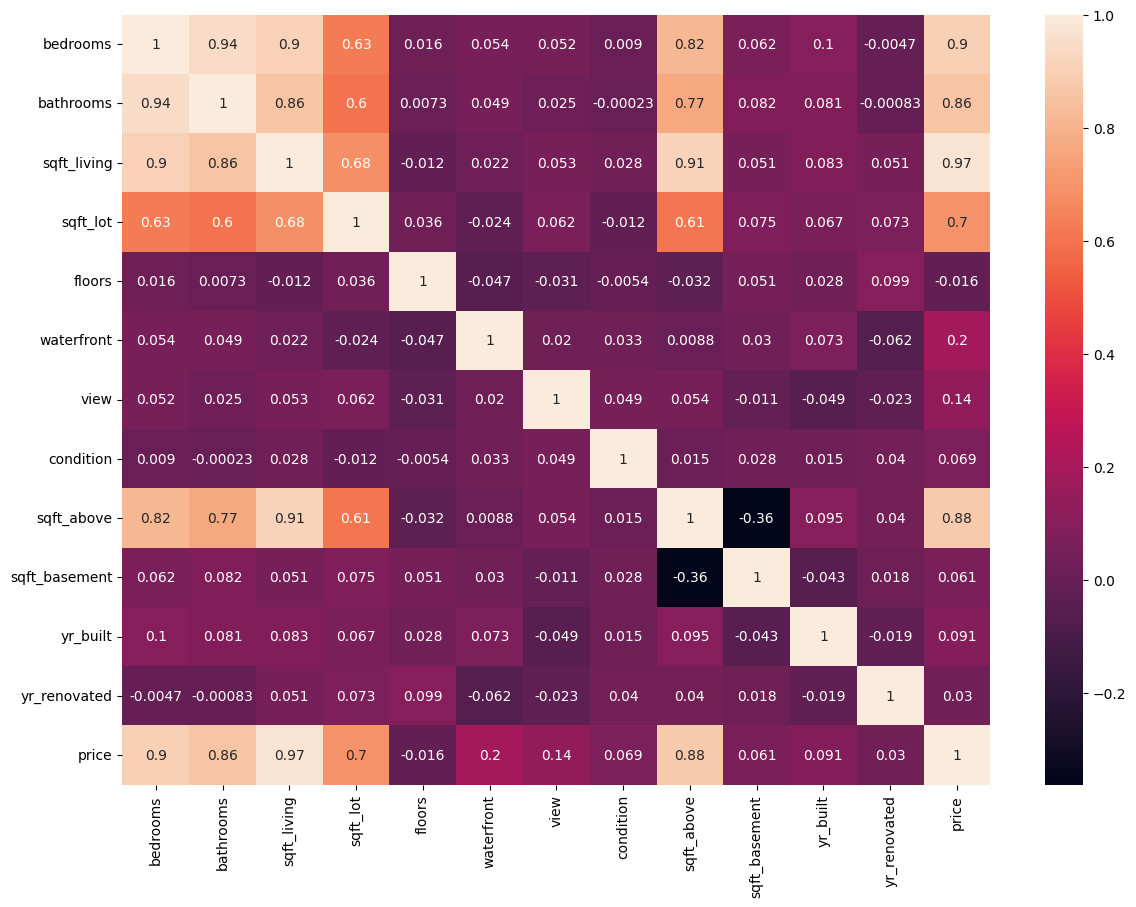

In [13]:
plt.figure(figsize=(14,10))
sns.heatmap(dataset.corr(),annot=True)

In [14]:
x=dataset.iloc[:,:-1]
y=dataset['price']
sc=StandardScaler()
x=pd.DataFrame(sc.fit_transform(x),columns=x.columns)



In [15]:
dataset.isnull().sum()

bedrooms         0
bathrooms        0
sqft_living      0
sqft_lot         0
floors           0
waterfront       0
view             0
condition        0
sqft_above       0
sqft_basement    0
yr_built         0
yr_renovated     0
price            0
dtype: int64

In [16]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

linear refression

In [17]:
lr=LinearRegression()
lr.fit(x_train,y_train)
lr.score(x_test,y_test)*100



98.25057183869961

<BarContainer object of 12 artists>

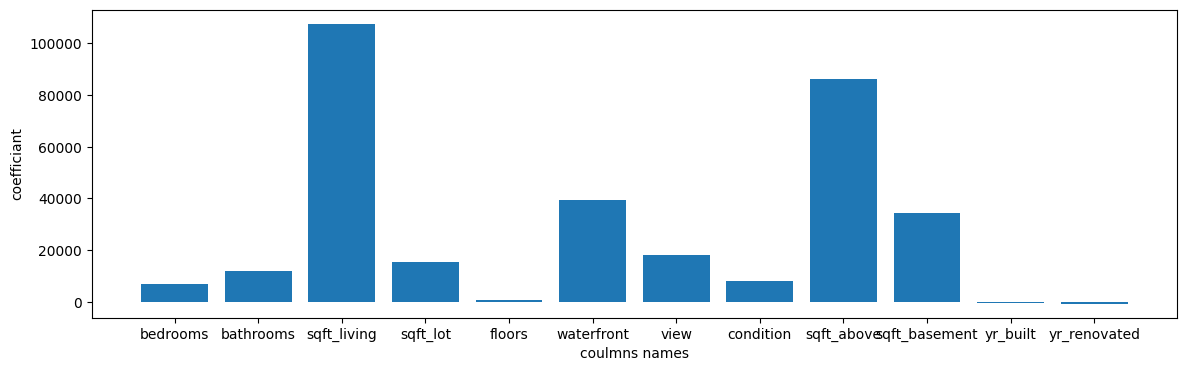

In [18]:
plt.figure(figsize=(14,4))
plt.xlabel('coulmns names')
plt.ylabel("coefficiant")
plt.bar(x.columns,lr.coef_)

ridge linear regression



In [19]:
rid=Ridge(alpha=2)
rid.fit(x_train,y_train)

rid.score(x_test,y_test)*100

98.26446471195892

<BarContainer object of 12 artists>

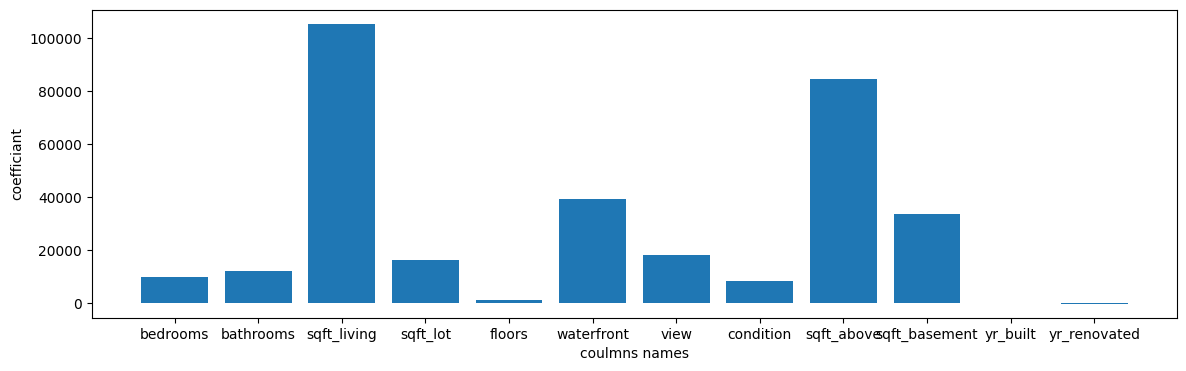

In [20]:
plt.figure(figsize=(14,4))
plt.xlabel('coulmns names')
plt.ylabel("coefficiant")
plt.bar(x.columns,rid.coef_)

lasso linear regression













In [21]:
lasso=Lasso(alpha=2)
lasso.fit(x_train,y_train)

lasso.score(x_test,y_test)*100

c:\Users\layap\AppData\Local\Programs\Python\Python39\lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.520e+09, tolerance: 2.055e+09
  model = cd_fast.enet_coordinate_descent(


98.2505293493957

<BarContainer object of 12 artists>

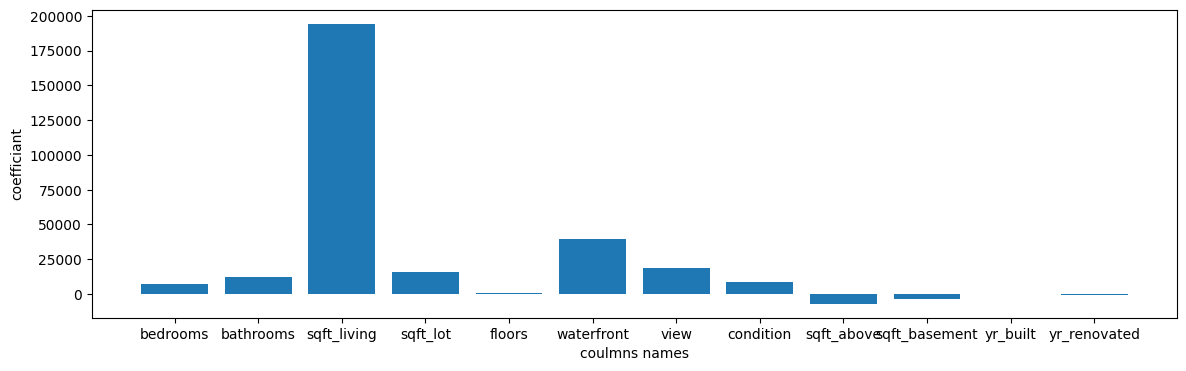

In [22]:
plt.figure(figsize=(14,4))
plt.xlabel('coulmns names')
plt.ylabel("coefficiant")
plt.bar(x.columns,lasso.coef_)